# Part 1 — Exploratory Data Analysis and Statistics

**Project:** Privacy Risk Analysis and Automatic Classification in the GPT Plugin Ecosystem

**In this section:**
- We'll examine the dataset's basic structure (row/column counts, missing values, types)
- We'll visualize the category distributions
- **Research Question 1:** How is the data requested by GPT plugins distributed across categories, and what share of the total do sensitive categories make up?
- **Research Question 2:** Does the rate of writing a description differ between sensitive and non-sensitive categories? (statistical test)

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_PATH = '../backend/data/data_entries_final.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
df.shape

(12811, 6)

## Step 2 — Examining the Data Structure

We've loaded the data but haven't looked at its contents yet. In this step we check three things:

1. **Column types** — `plugin_id_filenames` is a list column, the rest are text. We're checking whether pandas read them correctly.
2. **Missing values** — how many records have the `description` column left blank in particular? This will be our reference point for Research Question 2 (description-writing rate in sensitive vs. non-sensitive categories).
3. **Sample rows** — to see with our own eyes what the data actually looks like, as a sanity check before trusting the numbers.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12811 entries, 0 to 12810
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   index                12811 non-null  int64 
 1   plugin_id_filenames  12811 non-null  object
 2   name                 12811 non-null  object
 3   description          12811 non-null  object
 4   main_data_type       12811 non-null  object
 5   data_type            12811 non-null  object
dtypes: int64(1), object(5)
memory usage: 600.6+ KB


Note: in text columns like `description`, "missing data" is usually stored not as `NaN` but as an **empty string (`""`)**. So checking with just `.isna()` would be misleading — we count empty strings separately too.

In [3]:
text_cols = ['name', 'description', 'main_data_type', 'data_type']

missing_summary = pd.DataFrame({
    'null_count': df[text_cols].isna().sum(),
    'empty_string_count': (df[text_cols] == '').sum(),
})
missing_summary['effectively_missing'] = missing_summary['null_count'] + missing_summary['empty_string_count']
missing_summary['pct_missing'] = (missing_summary['effectively_missing'] / len(df) * 100).round(2)
missing_summary

                null_count  empty_string_count  effectively_missing  \
name                     0                   1                    1   
description              0                1999                 1999   
main_data_type           0                   0                    0   
data_type                0                   0                    0   

                pct_missing  
name                   0.01  
description           15.60  
main_data_type         0.00  
data_type              0.00  

In [4]:
df.sample(5, random_state=42)

       index                                plugin_id_filenames         name  \
772      772             [g-2Eo3NxuS7_DX9y1883rIre0QLOgDFhKZit]        files   
10196  10196  [g-nU9eHhPrc_gzm_cnf_XgzC7h8mvJI9f4uI9IAghnGS~...       chunks   
385      385  [g-009xFjOLC_OoDqO0qGP1tw2zGRYCYIfpUK, g-2UZly...   user_email   
4269    4269  [g-GN0Zq0iZP_gzm_cnf_GpnRX0zniTgU24lIsjHtynV1~...  identifiers   
8          8  [g-dnFnjifmN_gzm_cnf_JriSWBp4x1f0ITBun22ZIjjq~...  num_results   

                                             description  \
772                List of files to include in the Repl.   
10196  Splits patterns or html into the amount of chu...   
385    Email of the user. Has to be a real active ema...   
4269              Filter by identifiers, comma-separated   
8      How many results to return. Defaults to 5. It ...   

             main_data_type                data_type  
772     Files and documents                File list  
10196        App usage data  Current session set

## Step 3 — Category Distributions (Research Question 1)

The `main_data_type` column has 25 distinct categories. First we'll look at the count for each, to see which categories dominate the dataset and which are rare (how long the tail is — this will also be useful for the clustering and modeling steps).

Then we get to the actual question: what share of the total data do the **"sensitive" categories** — `Security credentials`, `Personal information`, `Health information`, `Finance information` — make up? We'll compute this both as a count and a percentage, and visualize it in a single chart (marking sensitive categories in red, the rest in neutral gray).

In [5]:
category_counts = df['main_data_type'].value_counts()
category_pct = (category_counts / len(df) * 100).round(2)

category_table = pd.DataFrame({'count': category_counts, 'pct': category_pct})
category_table

                                count    pct
main_data_type                              
App usage data                   2568  20.05
Identifier                       1888  14.74
Other                            1721  13.43
Query                            1416  11.05
Time                             1131   8.83
Web and network data              925   7.22
Location                          701   5.47
Personal information              435   3.40
Files and documents               412   3.22
Market data                       367   2.86
Security credentials              276   2.15
Message                           192   1.50
App metadata                      138   1.08
Finance information               138   1.08
Health information                 82   0.64
E-commerce data                    66   0.52
Travel information                 58   0.45
Sports information                 57   0.44
Event information                  51   0.40
Vehicle information                42   0.33
Real estat

In [6]:
SENSITIVE_CATEGORIES = [
    'Security credentials',
    'Personal information',
    'Health information',
    'Finance information',
]

df['is_sensitive'] = df['main_data_type'].isin(SENSITIVE_CATEGORIES)

sensitive_summary = df['is_sensitive'].value_counts().rename({True: 'Sensitive', False: 'Not sensitive'})
sensitive_pct = (sensitive_summary / len(df) * 100).round(2)

print(pd.DataFrame({'count': sensitive_summary, 'pct': sensitive_pct}))
print()
print('Breakdown of sensitive categories:')
print(category_table.loc[SENSITIVE_CATEGORIES])

               count    pct
is_sensitive               
Not sensitive  11880  92.73
Sensitive        931   7.27

Breakdown of sensitive categories:
                      count   pct
main_data_type                   
Security credentials    276  2.15
Personal information    435  3.40
Health information       82  0.64
Finance information     138  1.08


### Addendum: Sensitive categories only, by frequency

The full distribution chart above shows all 25 categories. Here we focus on just the 4 sensitive categories and clearly visualize which of them appears most often.

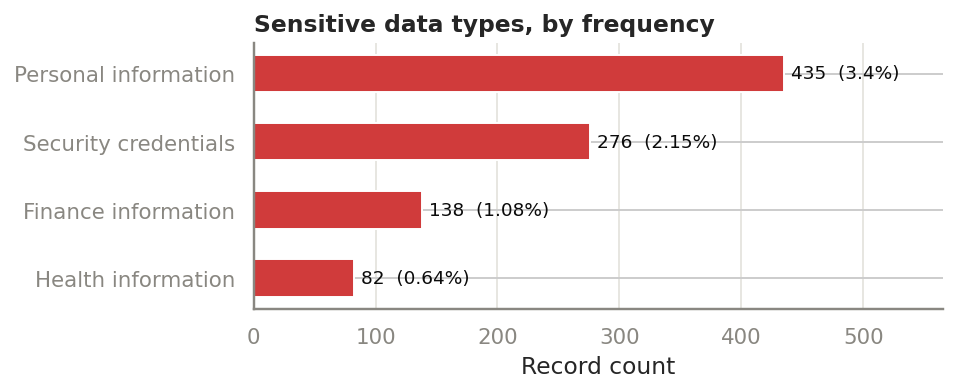

In [7]:
COLOR_SENSITIVE = '#d03b3b'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

sensitive_table = category_table.loc[SENSITIVE_CATEGORIES].sort_values('count')

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(sensitive_table.index, sensitive_table['count'], color=COLOR_SENSITIVE, height=0.55)

for bar, count, pct in zip(bars, sensitive_table['count'], sensitive_table['pct']):
    ax.text(bar.get_width() + 6, bar.get_y() + bar.get_height() / 2,
            f'{count}  ({pct}%)', va='center', ha='left', fontsize=9.5, color=COLOR_TEXT)

ax.set_xlabel('Record count')
ax.set_title('Sensitive data types, by frequency', loc='left', fontsize=12, fontweight='bold')
ax.set_xlim(0, sensitive_table['count'].max() * 1.3)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq1_sensitive_breakdown.png', dpi=150, bbox_inches='tight')

plt.show()

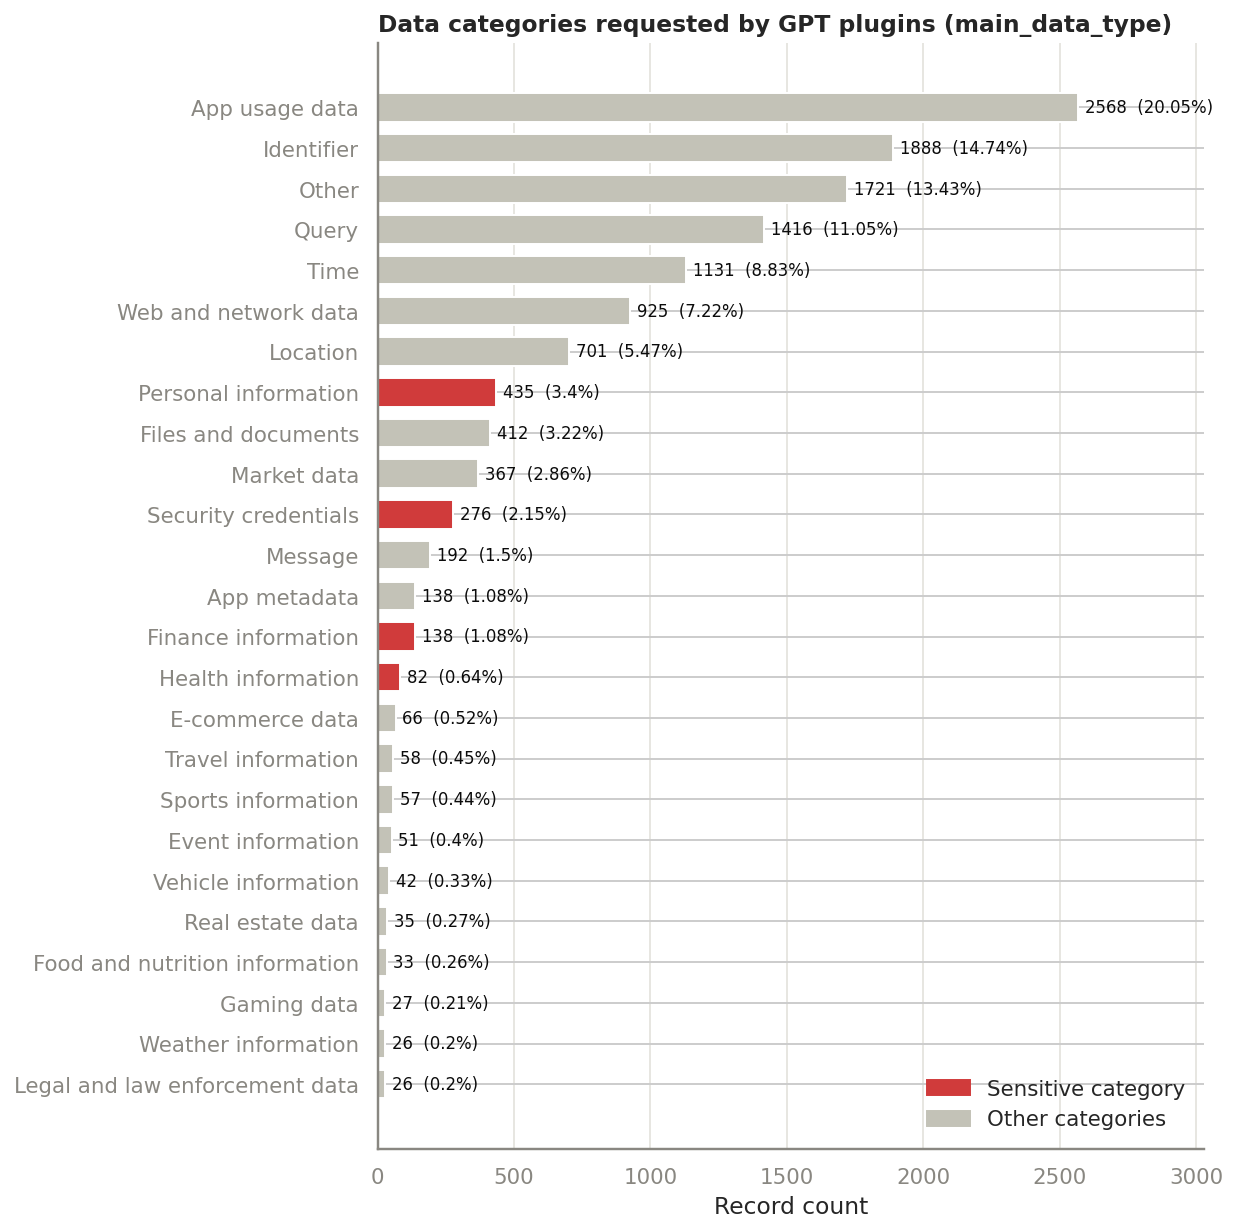

In [8]:
COLOR_SENSITIVE = '#d03b3b'
COLOR_NEUTRAL = '#c3c2b7'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

ordered = category_table.sort_values('count', ascending=True)
colors = [COLOR_SENSITIVE if cat in SENSITIVE_CATEGORIES else COLOR_NEUTRAL for cat in ordered.index]

fig, ax = plt.subplots(figsize=(9, 9))
bars = ax.barh(ordered.index, ordered['count'], color=colors, height=0.7)

for bar, count, pct in zip(bars, ordered['count'], ordered['pct']):
    ax.text(bar.get_width() + 25, bar.get_y() + bar.get_height() / 2,
            f'{count}  ({pct}%)', va='center', ha='left', fontsize=8.5, color=COLOR_TEXT)

ax.set_xlabel('Record count')
ax.set_title('Data categories requested by GPT plugins (main_data_type)', loc='left', fontsize=12, fontweight='bold')
ax.set_xlim(0, ordered['count'].max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLOR_SENSITIVE, label='Sensitive category'),
    plt.Rectangle((0, 0), 1, 1, color=COLOR_NEUTRAL, label='Other categories'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=False)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq1_category_distribution.png', dpi=150, bbox_inches='tight')

plt.show()

### Finding (Research Question 1)

As the chart shows, the distribution is quite skewed: the top three categories (`App usage data`, `Identifier`, `Other`) alone make up roughly half the data, while the remaining 22 categories form a long, shrinking tail.

Below we summarize, in one clear sentence, what share of the total the four sensitive categories we defined (`Security credentials`, `Personal information`, `Health information`, `Finance information`) make up.

In [9]:
n_sensitive = int(df['is_sensitive'].sum())
pct_sensitive = round(n_sensitive / len(df) * 100, 1)

top3 = category_counts.head(3)
pct_top3 = round(top3.sum() / len(df) * 100, 1)

print(f"The top 3 categories ({', '.join(top3.index)}) make up {pct_top3}% of the total.")
print(f"The 4 sensitive categories (Security credentials, Personal information, Health information, Finance information) "
      f"make up {pct_sensitive}% of the data, with {n_sensitive} records total.")

The top 3 categories (App usage data, Identifier, Other) make up 48.2% of the total.
The 4 sensitive categories (Security credentials, Personal information, Health information, Finance information) make up 7.3% of the data, with 931 records total.


## Step 4 — Description-Writing Rate: Selected Sensitive vs. Other Categories (Research Question 2)

Intuitively, one might expect that if a parameter requests sensitive data (e.g. a password or health information), the developer would take more care to describe it — clearly explaining to the user why it's needed. Here we test that: **is the rate at which parameters in sensitive categories have a description genuinely different from non-sensitive ones, or is the difference we see just random fluctuation?**

In Step 2 we saw that a missing `description` is stored as an empty string, not `NaN`; we use that same definition here. We have two categorical variables (is it sensitive / does it have a description), so the appropriate test is the **chi-square test of independence** — it checks whether there's an association between two categorical variables. We'll look not just at the p-value but also at how large the difference is in practice (via Cramér's V), because in a sample as large as 12,811, even tiny differences can come out "statistically significant."

In [10]:
df['has_description'] = df['description'] != ''

contingency = pd.crosstab(df['is_sensitive'], df['has_description'])
contingency.index = contingency.index.map({True: 'Sensitive', False: 'Not sensitive'})
contingency.columns = contingency.columns.map({True: 'Has description', False: 'No description'})
contingency

has_description  No description  Has description
is_sensitive                                    
Not sensitive              1824            10056
Sensitive                   175              756

In [11]:
contingency_pct = (contingency.div(contingency.sum(axis=1), axis=0) * 100).round(2)
contingency_pct

has_description  No description  Has description
is_sensitive                                    
Not sensitive             15.35            84.65
Sensitive                 18.80            81.20

In [12]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency)

n = contingency.values.sum()
k = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))

print(f'Chi-square statistic: {chi2:.3f}')
print(f'p-value: {p_value:.4f}')
print(f'Degrees of freedom: {dof}')
print(f"Cramér's V (effect size): {cramers_v:.4f}")

Chi-square statistic: 7.514
p-value: 0.0061
Degrees of freedom: 1
Cramér's V (effect size): 0.0242


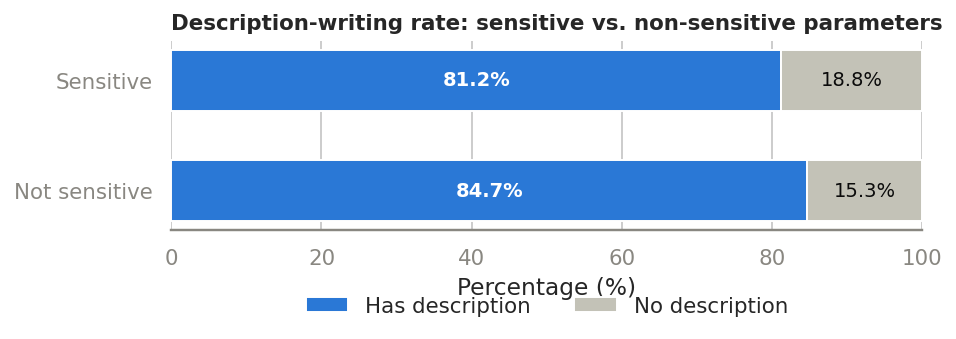

In [13]:
COLOR_HAS_DESC = '#2a78d6'
COLOR_NO_DESC = '#c3c2b7'

groups = contingency_pct.index.tolist()
has_desc_pct = contingency_pct['Has description']
no_desc_pct = contingency_pct['No description']

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(groups, has_desc_pct, color=COLOR_HAS_DESC, height=0.55, label='Has description')
ax.barh(groups, no_desc_pct, left=has_desc_pct, color=COLOR_NO_DESC, height=0.55, label='No description')

for i, group in enumerate(groups):
    ax.text(has_desc_pct[group] / 2, i, f'{has_desc_pct[group]:.1f}%',
            va='center', ha='center', fontsize=10, color='white', fontweight='bold')
    ax.text(has_desc_pct[group] + no_desc_pct[group] / 2, i, f'{no_desc_pct[group]:.1f}%',
            va='center', ha='center', fontsize=10, color=COLOR_TEXT)

ax.set_xlim(0, 100)
ax.set_xlabel('Percentage (%)')
ax.set_title('Description-writing rate: sensitive vs. non-sensitive parameters', loc='left', fontsize=11, fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED, left=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq2_description_rate.png', dpi=150, bbox_inches='tight')

plt.show()

### Finding (Research Question 2)

The result is the **opposite** of our intuition: the description-writing rate for parameters in sensitive categories (81.2%, 95% Wilson CI [78.6%, 83.6%]) is slightly **lower** than for non-sensitive ones (84.65%, CI [84.0%, 85.3%]) — i.e., developers describe parameters that request sensitive data slightly *less*, not more. The difference is small but the confidence intervals barely overlap (paired bootstrap estimate: **-3.4 points, CI [-6.0, -1.0]**).

The chi-square test says this difference isn't random (p ≈ 0.006, below the 5% significance threshold), meaning there's a statistically significant association. But Cramér's V ≈ 0.024 — meaning the relationship between the two variables is **practically very weak**. In short: thanks to the large sample of 12,811 records, even a tiny difference can come out "statistically significant," but the real-world effect of that difference is negligible. Practical takeaway: **whether a parameter is sensitive or not barely predicts whether it has a description** — the lack of a description looks like a general habit, independent of category.

One caveat worth stating plainly: the chi-square test and these confidence intervals assume each parameter record is an independent observation. In practice, plugins that reuse the same description template across many parameters could violate that assumption — the association is real, but "how independently informative" each of the 12,811 rows really is stays an open question.

## Summary — Part 1

**Dataset:** 12,811 parameter records, 6 columns. `name` and `main_data_type`/`data_type` are almost never empty; `description` is empty for **15.6%** of records (1,999 records) — meaning that later, when doing text-based classification (Part 2), part of our available text signal will be weak.

**Research Question 1 — Category distribution:**
- `main_data_type` has a skewed distribution: the top 3 categories (`App usage data`, `Identifier`, `Other`) cover **48.2%** of the data.
- The sensitive categories (`Security credentials`, `Personal information`, `Health information`, `Finance information`) total **931 records (7.3%)** — a small but meaningful slice; Personal information (435 records, 3.4%) and Security credentials (276 records, 2.15%) are the sensitive data types GPT plugins request relatively often, while Finance information (138, 1.08%) and Health information (82, 0.64%) are rarer.

**Research Question 2 — Description-writing rate:**
- The description-writing rate in sensitive categories (81.2%) is slightly **lower** than in non-sensitive ones (84.65%) — the opposite direction from what we expected.
- The chi-square test finds this difference statistically significant (p ≈ 0.006), but the effect size (Cramér's V ≈ 0.024) is negligibly small. So sensitivity barely predicts, in practice, whether a parameter has a description.

**Notes to carry into Part 2:**
- The `data_type` column has 145 distinct values, and the distribution is extremely long-tailed. This means that when building the text classification model, we'll need to carefully choose which target column to use (`main_data_type` or `data_type`) and how to handle rare classes.